In [1]:
%load_ext autoreload
%autoreload 2
# %matplotlib inline

import os
while 'notebooks' in os.getcwd():
    os.chdir("../")

!pwd

/Users/msat/projects/SemanticPullbacks


In [2]:
import platform
platform.machine()

'arm64'

In [ ]:
import torch
import math
from torch import nn, einsum
from torchvision.datasets import Imagenette
from torch.utils.data import DataLoader

import torch.nn.functional as F
from torchvision import transforms as T

from lib.dataset import get_dataset, get_examples, FromMyNormalizeToImageNet
from lib.pga import PGA
from lib.helpers import plot_example_grid, replace_module_with_custom_, maxpool2d_param_extractor, batchnorm_param_extractor, layernorm_param_extractor, plot_function, show_images
from lib.surrogates import SurrogateSoftMaxPool2d, SurrogateLayerNorm, SurrogateLayerNorm2d, DetachedAttention

In [4]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
device = torch.device(device)
device

device(type='mps')

In [5]:
try:
    dataset = get_dataset(download=True)
except RuntimeError as e:
    # wierdly, Imagenette raises error if already downloaded (at least in some torchvision versions)
    print(e)
    dataset = get_dataset(download=False)

seed = 314
generator = torch.Generator().manual_seed(seed)
loader = DataLoader(dataset, batch_size=5, shuffle=True, generator=generator)

tensor(-1.) tensor(1.) tensor(-0.1605) tensor(0.5643)
images.shape = torch.Size([5, 3, 224, 224])
labels = [0, 482, 497, 569, 574]


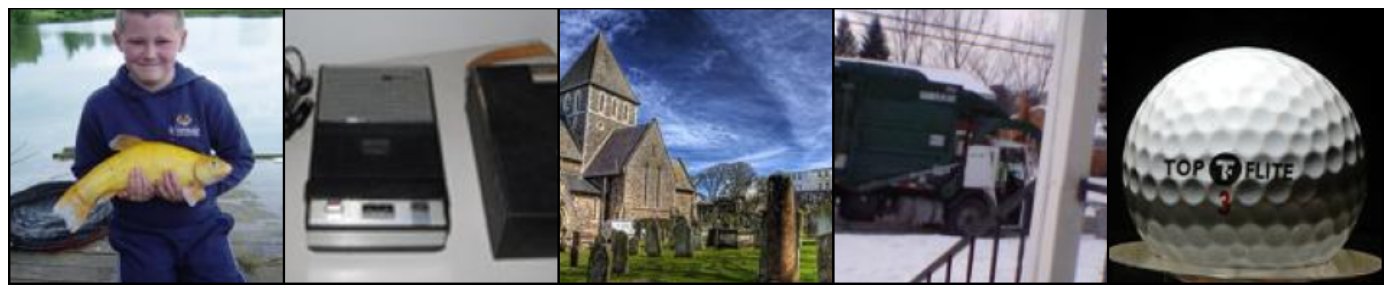

In [6]:
images, labels = get_examples(loader)

print(images.min(), images.max(), images.mean(), images.std())
print(f"images.shape = {images.shape}")
print(f"labels = {labels.tolist()}")

plot_example_grid(images, nrow=5)

In [16]:
from torchvision.models import resnet50, resnet18, vgg11_bn, densenet121, vit_b_16, convnext_tiny, efficientnet_b0, resnet18, squeezenet1_1, resnext50_32x4d

model_cls = resnet18
# model_cls = resnet50
# model_cls = densenet121
# model_cls = vgg11_bn
# model_cls = vit_b_16
# model_cls = resnet18
# model_cls = efficientnet_b0
# model_cls = squeezenet1_1
# model_cls = convnext_tiny
# model_cls = resnext50_32x4d

backbone_std = model_cls(pretrained=True)
backbone = model_cls(pretrained=True)

/Users/msat/.venvs/quantus/lib/python3.14/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/msat/.venvs/quantus/lib/python3.14/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
import quantus
from quantus import Metric, explain
import captum
# from quantus.metrics.base import Metric

In [14]:
quantus.MaxSensitivity().get_params

{'abs': False,
 'normalise': False,
 'return_aggregate': False,
 'aggregate_func': <function mean at 0x10e01fb30>,
 'normalise_func': <function quantus.functions.normalise_func.normalise_by_max(a: numpy.ndarray, normalise_axes: Sequence[int] | None = None) -> numpy.ndarray>,
 'normalise_func_kwargs': {},
 '_disable_warnings': False,
 '_display_progressbar': False,
 'a_axes': None,
 'nr_samples': 200,
 'similarity_func': <function quantus.functions.similarity_func.difference(a: <built-in function array>, b: <built-in function array>, **kwargs) -> <built-in function array>>,
 'norm_numerator': <function quantus.functions.norm_func.fro_norm(a: <built-in function array>) -> float>,
 'norm_denominator': <function quantus.functions.norm_func.fro_norm(a: <built-in function array>) -> float>,
 'perturb_func': functools.partial(<function batch_uniform_noise at 0x1432a3270>, lower_bound=0.2, upper_bound=None),
 'changed_prediction_indices_func': functools.partial(<function changed_prediction_ind

In [13]:
quantus.AVAILABLE_METRICS

{'Faithfulness': {'Faithfulness Correlation': quantus.metrics.faithfulness.faithfulness_correlation.FaithfulnessCorrelation,
  'Faithfulness Estimate': quantus.metrics.faithfulness.faithfulness_estimate.FaithfulnessEstimate,
  'Pixel-Flipping': quantus.metrics.faithfulness.pixel_flipping.PixelFlipping,
  'Region Segmentation': quantus.metrics.faithfulness.region_perturbation.RegionPerturbation,
  'Monotonicity-Arya': quantus.metrics.faithfulness.monotonicity.Monotonicity,
  'Monotonicity-Nguyen': quantus.metrics.faithfulness.monotonicity_correlation.MonotonicityCorrelation,
  'Selectivity': quantus.metrics.faithfulness.selectivity.Selectivity,
  'SensitivityN': quantus.metrics.faithfulness.sensitivity_n.SensitivityN,
  'IROF': quantus.metrics.faithfulness.irof.IROF,
  'ROAD': quantus.metrics.faithfulness.road.ROAD,
  'Infidelity': quantus.metrics.faithfulness.infidelity.Infidelity,
  'Sufficiency': quantus.metrics.faithfulness.sufficiency.Sufficiency},
 'Robustness': {'Continuity Test'

In [15]:
quantus.AVAILABLE_XAI_METHODS_CAPTUM

['GradientShap',
 'IntegratedGradients',
 'DeepLift',
 'DeepLiftShap',
 'InputXGradient',
 'Saliency',
 'FeatureAblation',
 'Deconvolution',
 'FeaturePermutation',
 'Lime',
 'KernelShap',
 'LRP',
 'Gradient',
 'Occlusion',
 'LayerGradCam',
 'GuidedGradCam',
 'LayerConductance',
 'LayerActivation',
 'InternalInfluence',
 'LayerGradientXActivation',
 'Control Var. Sobel Filter',
 'Control Var. Constant',
 'Control Var. Random Uniform']

In [ ]:
# explanation metod:
# - create surrogate model (with temp hyperparams)
# - perform PGA toward chosen class

In [ ]:
# temp = 0.8
# temp = 1.2
temp = 1.
# temp = 0.2
# temp = 0.3
# temp = 0.001
# temp = 100.
# act = "relu"
act = "gelu"
# act = "silu"

# replace_module_with_custom_(model[1].classifier, lambda: TwoWayReLU(temperature=temp, act=act), original_cls=nn.ReLU)#, by_name='relu')
# replace_module_with_custom_(model, lambda: TwoWayReLU(temperature=temp, act=act), original_cls=nn.ReLU)#, by_name='relu')
replace_module_with_custom_(model, lambda: TwoWayReLU(temperature=temp, act=act), original_cls=TwoWayReLU)
# replace_module_with_custom_(model, lambda: nn.ReLU(), original_cls=TwoWayReLU)
# replace_module_with_custom_(model, lambda: TwoWayReLU(temperature=temp, act=act), original_cls=nn.GELU, param_extractor=None)#, by_name='relu')
# replace_module_with_custom_(model, lambda: TwoWayReLU(temperature=temp, act=act), original_cls=nn.SiLU)#, by_name='relu')

replace_module_with_custom_(model, lambda **params: SurrogateSoftMaxPool2d(**params, temperature=0.3), original_cls=nn.MaxPool2d, param_extractor=maxpool2d_param_extractor)
# replace_module_with_custom_(model, lambda **params: SurrogateSoftMaxPool2d(**params, temperature=0.2), original_cls=SurrogateSoftMaxPool2d, param_extractor=maxpool2d_param_extractor)

# replace_module_with_custom_(model, lambda **params: SurrogateLayerNorm2d(**params), original_cls=LayerNorm2d, param_extractor=layernorm_param_extractor)
replace_module_with_custom_(model, lambda **params: SurrogateLayerNorm(**params), original_cls=nn.LayerNorm, param_extractor=layernorm_param_extractor)

replace_module_with_custom_(model, DetachedAttention, original_cls=nn.MultiheadAttention, param_extractor=None, replace_class=True)
# replace_module_with_custom_(model, nn.MultiheadAttention, original_cls=DetachedAttention, param_extractor=None, replace_class=True)


In [ ]:
# def your_own_callable(model, inputs, targets, **kwargs) -> np.ndarray:
#   """Logic goes here to compute the attributions and return an 
#   explanation  in the same shape as x_batch (np.array), 
#   (flatten channels if necessary)."""
#   return explanation(model, inputs, targets)

# scores = metric(
#     model=model,
#     x_batch=x_batch,
#     y_batch=y_batch,
#     device=device,
#     explain_func=your_own_callable
# )